# Phase 3 — Transaction costs (NSE intraday cost model)

Each round trip = 4 fills (open A, open B, close A, close B). Charged per fill:

| Item | Rate | Side |
|---|---|---|
| Brokerage | min(0.03%, ₹20) per order | both |
| STT (intraday) | 0.025% | **sell only** |
| NSE transaction charge | 0.00297% | both |
| SEBI fee | ₹10 / crore | both |
| Stamp duty (intraday) | 0.003% | **buy only** |
| GST | 18% on brokerage + exchange + SEBI | both |
| Slippage | `SLIPPAGE_BPS` (default 2 bps) | both |

The slippage default is NSE-specific, not the US 3 bps habit. The reasoning is in `src/costs.py`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))   # make /src importable

import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
%matplotlib inline

In [2]:
from data_pipeline import load_universe, split_formation_trading
from cointegration import FORMATION_DAYS, screen_pairs, select_pairs_for_trading

universe = load_universe()                      # cached parquet in /data; refresh=True to re-download
formation = {k: split_formation_trading(v, FORMATION_DAYS)[0] for k, v in universe.items()}
phase1 = screen_pairs(formation)
selected, used_fallback = select_pairs_for_trading(phase1)
PAIR = selected[0]
prices = universe[PAIR]
trade_start = split_formation_trading(prices, FORMATION_DAYS)[1].index[0]
print(f"Trading pair: {PAIR}   fallback used: {used_fallback}   trading period starts {trade_start}")

Trading pair: SBIN/BANKBARODA   fallback used: True   trading period starts 2026-07-30 09:15:00+05:30


## 1. What does one round trip cost?

In [3]:
from costs import IndianEquityCostModel, round_trip_breakdown, SLIPPAGE_BPS
from strategy import NOTIONAL_PER_LEG

cm = IndianEquityCostModel()
bd = pd.Series(round_trip_breakdown(NOTIONAL_PER_LEG, cm))
bd_tbl = pd.DataFrame({"INR": bd.round(1), "bps of one leg": (bd / NOTIONAL_PER_LEG * 1e4).round(2)})
bd_tbl.loc["TOTAL"] = bd_tbl.sum()
print(f"Round trip on Rs {NOTIONAL_PER_LEG:,.0f} per leg; slippage = {SLIPPAGE_BPS} bps per fill")
bd_tbl

Round trip on Rs 500,000 per leg; slippage = 2.0 bps per fill


,INR,bps of one leg
brokerage,80.0,1.60
stt,250.0,5.00
exchange,59.4,1.19
sebi,2.0,0.04
stamp_duty,30.0,0.60
gst,25.5,0.51
slippage,400.0,8.00
TOTAL,846.9,16.94


**Break-even intuition:** the spread has to revert by more than the round-trip cost (in bps of one leg's notional) on an average trade, just to break even. Slippage and STT dominate, so the regulatory fees hardly matter.

## 2. Re-run the Phase 2 backtest with costs

In [4]:
from strategy import build_signals, run_backtest
from backtest_report import cost_comparison_table, format_table, plot_equity, plot_drawdown

sig = build_signals(prices, trade_start=trade_start)
gross = run_backtest(sig, label="before costs")
net = run_backtest(sig, cost_model=cm, label="after costs")
format_table(cost_comparison_table(gross, net))

,Before costs,After costs,Change
Total return,1.29%,-3.70%,-4.99%
Annualised return,7.60%,-19.44%,-27.05%
Annualised excess return,1.10%,-25.94%,-27.05%
Sharpe ratio,0.26,-6.17,-6.43
Max drawdown,-1.48%,-4.54%,-3.05%
Win rate,64.41%,42.37%,-22.03%
Number of trades,59,59,0
Avg net P&L / trade (INR),218,-628,-846
Total costs (INR),0,"49,923",-
Cost impact (% of gross P&L),-,387.77%,-


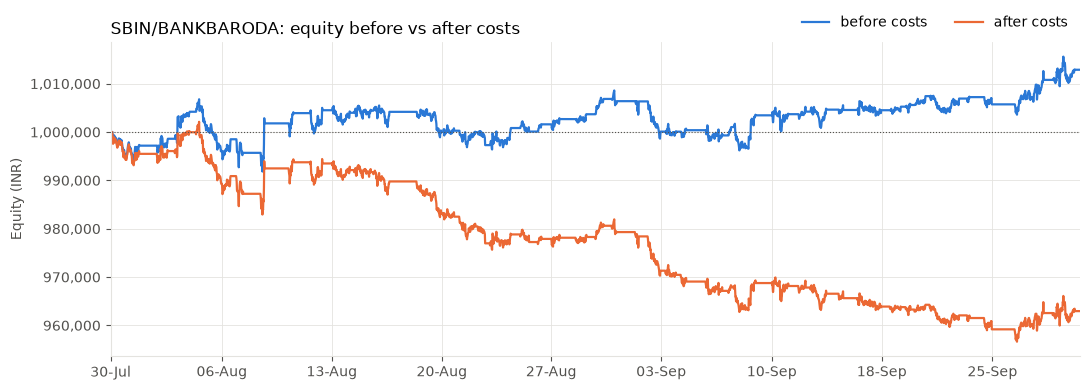

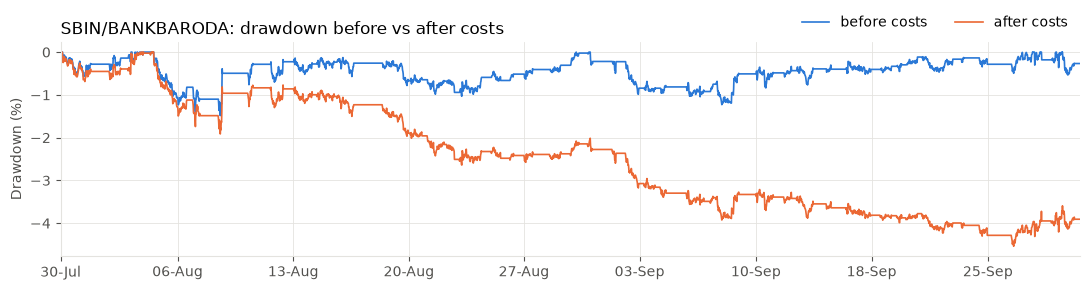

In [5]:
plot_equity([gross, net], f"{PAIR}: equity before vs after costs"); plt.show()
plot_drawdown([gross, net], f"{PAIR}: drawdown before vs after costs"); plt.show()

## 3. Slippage sensitivity
Slippage is the one input we **can't** measure from yfinance data (no bid/ask), so we report the full curve instead of defending a single number. The break-even slippage is where net P&L crosses zero.

In [6]:
from backtest_report import compute_metrics
import numpy as np

grid = [0, 0.5, 1, 2, 3, 5, 10]
sweep = pd.DataFrame({
    f"{s} bps": compute_metrics(run_backtest(sig, cost_model=IndianEquityCostModel(slippage_bps=s)))
    for s in grid
}).loc[["Total return", "Sharpe ratio", "Win rate", "Total costs (INR)"]]
format_table(sweep)

,0 bps,0.5 bps,1 bps,2 bps,3 bps,5 bps,10 bps
Total return,-1.35%,-1.94%,-2.53%,-3.70%,-4.88%,-7.24%,-13.14%
Sharpe ratio,-3.15,-3.91,-4.67,-6.17,-7.66,-10.53,-17.01
Win rate,50.85%,49.15%,45.76%,42.37%,35.59%,25.42%,10.17%
Total costs (INR),"26,346","32,240","38,134","49,923","61,712","85,289","144,233"


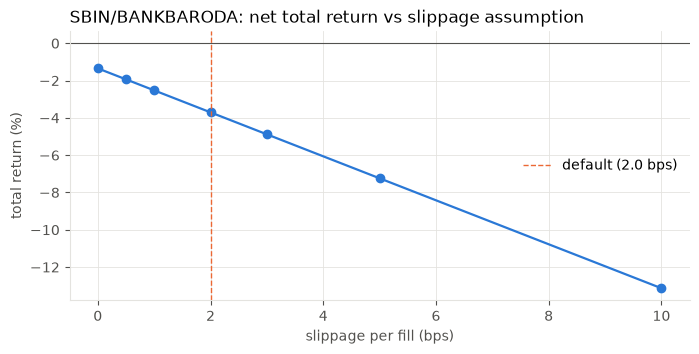

In [7]:
from backtest_report import SERIES_COLORS
tot = sweep.loc["Total return"].astype(float) * 100
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(grid, tot.values, color=SERIES_COLORS[0], marker="o")
ax.axhline(0, color="#52514e", lw=0.8)
ax.axvline(SLIPPAGE_BPS, color=SERIES_COLORS[1], ls="--", lw=1, label=f"default ({SLIPPAGE_BPS} bps)")
ax.set_xlabel("slippage per fill (bps)"); ax.set_ylabel("total return (%)")
ax.set_title(f"{PAIR}: net total return vs slippage assumption", loc="left"); ax.legend()
plt.show()

## 4. Cost impact across all candidate pairs
The same before/after structure for every pair, to show that the cost drag is not a quirk of one pair.

In [8]:
rows = {}
for k, px in universe.items():
    ts = split_formation_trading(px, FORMATION_DAYS)[1].index[0]
    s = build_signals(px, trade_start=ts)
    c = cost_comparison_table(run_backtest(s), run_backtest(s, cost_model=cm))
    rows[k] = {"Return before": c.loc["Total return", "Before costs"],
               "Return after": c.loc["Total return", "After costs"],
               "Trades": c.loc["Number of trades", "After costs"],
               "Total costs (INR)": c.loc["Total costs (INR)", "After costs"],
               "Excess-return degradation (ann.)": c.loc["Excess-return degradation (ann.)", "After costs"]}
pd.DataFrame(rows).T.style.format({"Return before": "{:.2%}", "Return after": "{:.2%}", "Trades": "{:.0f}",
                                   "Total costs (INR)": "{:,.0f}", "Excess-return degradation (ann.)": "{:.2%}"})

,Return before,Return after,Trades,Total costs (INR),Excess-return degradation (ann.)
HDFCBANK/ICICIBANK,-0.26%,-4.66%,52,"43,978",-22.43%
TCS/INFY,-1.83%,-6.22%,52,"43,923",-20.75%
SBIN/BANKBARODA,1.29%,-3.70%,59,"49,923",-27.05%
